# **決定木の実装例（その2）**

ここでは，第3章で整理した決定木の理論とアルゴリズムをデータ分析問題に適用してみます．分割基準や木の深さ，リーフノードの制約といった主要なハイパーパラメータが，モデルの振舞いにどのような影響を与えるのかも確認します．

## **回帰問題（フィッティング）**

ここでは，単純な線形回帰では捉えきれない非線形なデータ構造に対して，決定木がどのように適応するかを確認します．

以下では，説明変数 $X$ と目的変数 $y$ の間に，次の式で表される関係（真のモデル）が存在すると仮定します．

$$y = f(X)+\varepsilon \tag{1}$$

ここで，$f(X)$ は3次関数

$$f(X)=0.1(X+2)(X-2)(X-5)+2=0.1X^3-0.5X^2-0.4X+4$$

とし，$\varepsilon$ は観測時に混入する偶然誤差（ガウスノイズ）を表します．

データを用意し，この決定木による回帰モデル（回帰木）を構築し，回帰木を評価するというワークフローをステップに分けて解説していきます．

#### **■Step 0. ライブラリのインポート**

まず，必要なライブラリを一括してインポートします．

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, export_graphviz, plot_tree
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import os
import pandas as pd
import seaborn as sns
!pip install dtreeviz
!pip install graphviz
import dtreeviz
import graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 2.4 MB/s eta 0:00:00


#### **■Step 1.データの準備**

回帰木を作成するためにはまず，特徴量（問題を解くための入力データ）とターゲット（数値）を含むデータセットが必要です．

**Step 1**①はデータの生成です．ここではサンプルデータとして，次のコードにより，式$(2)$で表される真のモデルから200個の $(X,y)$ の組を入力データとして生成したものを利用することにします．

In [3]:
# データ生成（例: 3次関数）
np.random.seed(42)
X = np.arange(-2, 6, 0.04)
y = 0.1 * (X + 2) * (X - 2) * (X - 5) + 2 + np.random.normal(scale=0.3, size=len(X))

# 列ベクトルに変換
X = X.reshape(-1, 1)

$X$ は$-2$から6までの0.04間隔の数値です．一方，$y$は式$(2)$より計算されたものです．このデータセットを，

$$\text{(トレーニングデータ)}:\text{(テストデータ)}=4:1$$

にランダムに分割します．

ところで，$X$ は scikit-learn の決定木ライブラリに限らず，機械学習モデルに投入する際には列ベクトルになっていることが求められるので，7行目のように変換を行いました．この変換により，もともと

$$\lbrack - 2.00000000e + 00,\  - 1.96000000e + 00,\  - 1.92000000e + 00,\ldots\rbrack$$

という行ベクトルだった $X$ が，

$${\lbrack\lbrack - 2.00000000e + 00,\
}{- 1.96000000e + 00,
}{- 1.92000000e + 00,
}{- xxxxxxxx\ldots xxxxxxx\rbrack\rbrack}$$

という列ベクトルになります．なお，.reshape(-1,1)の「-1」は，「この次元のサイズを自動的に計算する」という意味です．例えば，1次元配列（shape=(n,)）を n 行1列の2次元配列（shape=(n,1)）に変換する場合，n の値を明示的に指定しなくても，総要素数に基づいて n が計算されるため，とても便利な書き方です．

**Step 1**②はデータの分割です．160個をトレーニングデータ，残りの40個のデータをテストデータとします．

In [4]:
# データ分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(160, 1)
(160,)
(40, 1)
(40,)


**Step 1**③はデータの可視化です．

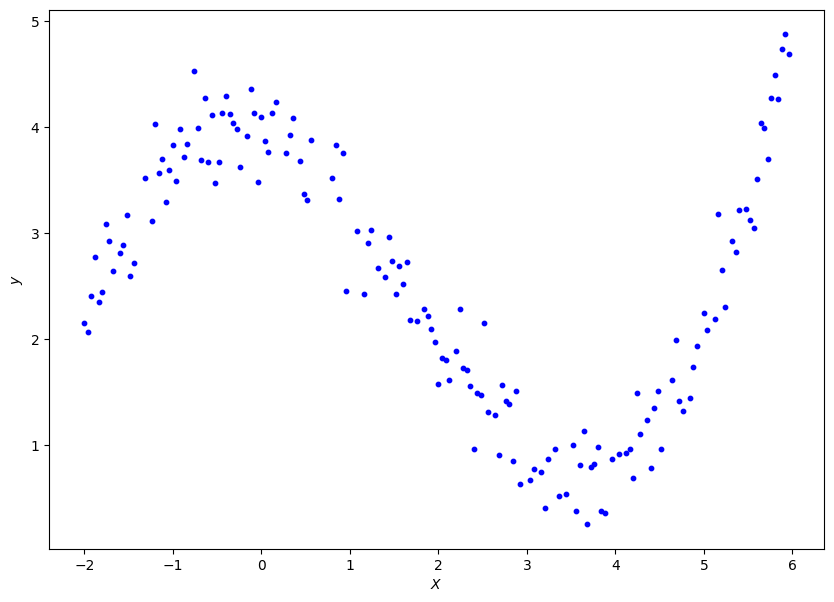

In [5]:
# 回帰直線を図示するのに変数を並び替え
sort_idx = X_train.flatten().argsort()

# プロット
plt.figure(figsize = (10, 7))
plt.scatter(X_train[sort_idx], y_train[sort_idx], c = 'blue', label = 'Training points', s=10)

plt.xlabel('$X$')
plt.ylabel('$y$')

plt.savefig("regression_4dPol.svg")
plt.show()

#### **■Step 2. 回帰木の初期設定**

回帰木構築の初期設定をしたうえで，全てのトレーニングデータをまとめて決定木の最初のノード，すなわちルートノードに入れます．回帰木の構築開始前に，子ノードを生成するのに使う特徴量・閾値の選び方を決めておきます．この選び方によって，回帰木アルゴリズムのバリエーションが生じます．

また，過学習を防ぐために，回帰木構築について次の初期設定をしておきます．

- **最大深さ**(max_depth)：決定木の深さを制限するパラメータです．深すぎると過学習を引き起こし，逆に浅すぎると過少学習に陥る可能性があります．適切な深さを設定することで，決定木の複雑さと汎化能力のバランスをとります．

- **最小分割サンプル数**(min_samples_split)：ノードを分割するために必要な最小のサンプル数を指定します．大きすぎると，ツリーが十分に成長できず，過少学習のリスクが高まります．逆に小さすぎると，過剰に分割されて過学習が引き起こされる可能性があります．

- **最小リーフサンプル数**(min_samples_leaf)：リーフノードに必要な最小のサンプル数を指定します．大きいと，リーフノードが過剰に制約されることでツリーが単純化され，過少学習につながる可能性があります．逆に小さすぎると，過学習のリスクが高まります．

- **最大リーフノード数**(max_leaf_nodes)：リーフノードの数の最大値を指定します．この制限により，決定木の構造を単純化し，モデルの汎化性能を向上させることが期待されます．ただし，値が大きすぎると木の複雑さが増し，過学習を引き起こす可能性があります．

上記のパラメータはデフォルト値がありますので，その前後で動かしながら適当な値を設定します．今回は次のように回帰木を設定することにします．

In [6]:
def build_tree(max_depth=5):

    tree = DecisionTreeRegressor(
        criterion='squared_error',   # 分割基準（MSE：平均二乗誤差）
        max_depth=max_depth,         # 最大深さ
        min_samples_leaf=2,          # リーフノードの最小サンプル数
        max_leaf_nodes=30,           # 最大リーフノード数
        random_state=42              # 再現性
    )
    return tree

本格的なモデル構築ではグリッドサーチ等を用いてパラメータを最適化しますが，本事例ではデータの構造が単純（3次関数＋ノイズ）であるため，主に max_depth によるモデルの変化を観察します．そのため，上のコードでは過学習抑制用のパラメータ（min_samples_leaf 等）は固定しつつ，深さを柔軟に変更できる関数を定義しました．

#### **■Step 3.子ノードを生成**

#### **■Step 4.終了条件を満たすまでの再帰的な木の成長**

**Step 3**では，**Step 2**で定義した関数を用いてモデルを初期化し，fit メソッドを呼び出すことで，ルートノードから子ノードの生成の生成を開始します．

**Step 4**では，**Step 3**で生成された子ノードのそれぞれに対して，同じ分割操作が再帰的に繰り返されます．すなわち，各子ノードのデータを対象として，再びMSEを最小化する特徴量と閾値を探索し，さらに子ノードを生成します．この操作は，**Step 2**で設定したいずれかの終了条件が満たされるまで続きます．

次のコードでは max_depth=5 に設定していますが，この引数を変えることで決定木の最大深さを調整することができます．

In [7]:
tree = build_tree(max_depth=5)
# 決定木を構築
tree.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=5, max_leaf_nodes=30, min_samples_leaf=2,
                      random_state=42)

#### **■Step 5.回帰木の評価**

決定木の最大深さ max_depth を変化させ，モデルの複雑さが予測結果にどのような影響を与えるかを確認します．深さの設定は，データの傾向をどれだけ忠実に学習するかをコントロールする重要な要素です．

- **深さが浅い場合**：モデルの表現力が低く，データの背後にある真の傾向（ここでは3次関数のカーブ）を捉えきれない単純なモデルになります．

- **深さを増やす場合**：データの細部まで学習できるようになりますが，深すぎるとデータに含まれるノイズまで学習してしまいます．これにより，訓練データには完全に適合するものの，未知のデータに対する予測精度が落ちる過学習のリスクが高まります．

**Step 3**では max_depth=5 に固定していましたが，ここでは max_depth を1から8まで段階的に変化させます．深さごとの「分割領域の変化（回帰直線の形状）」と「予測誤差 (MSE) 」を観察し，最適な深さがどこにあるのかを検討していきます．

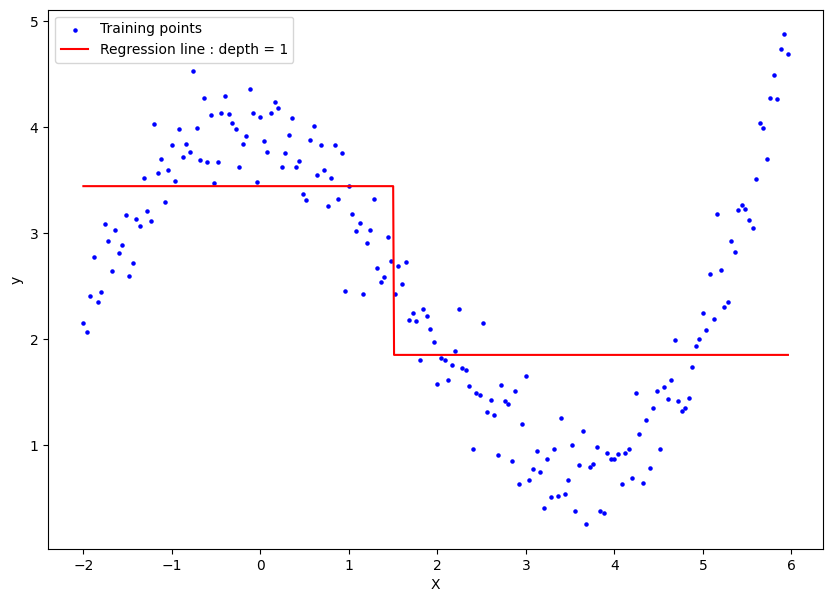

決定木を可視化中（深さ1まで表示）...


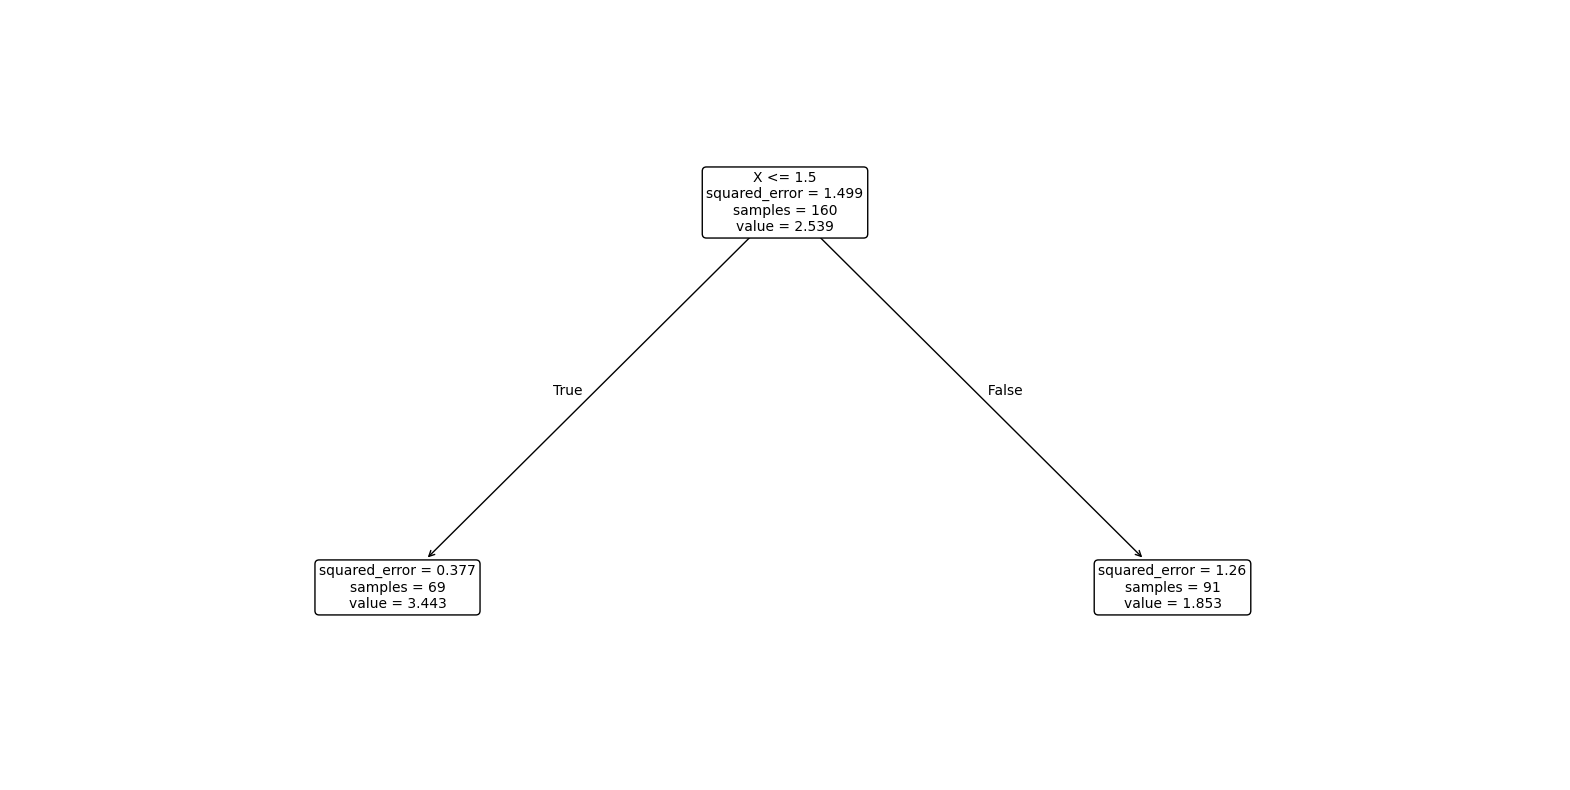

決定木の深さ1の可視化が decision_tree_visualization_depth1.svg に保存されました．


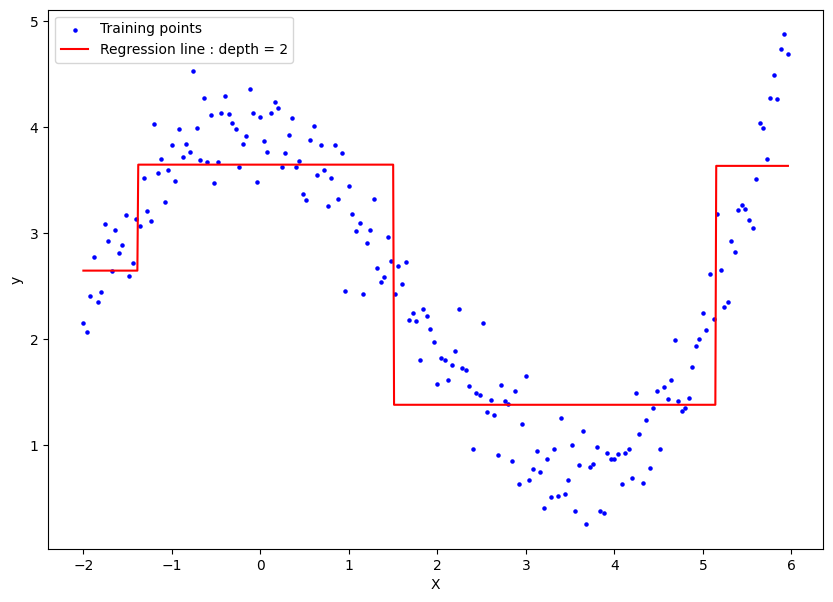

決定木を可視化中（深さ2まで表示）...


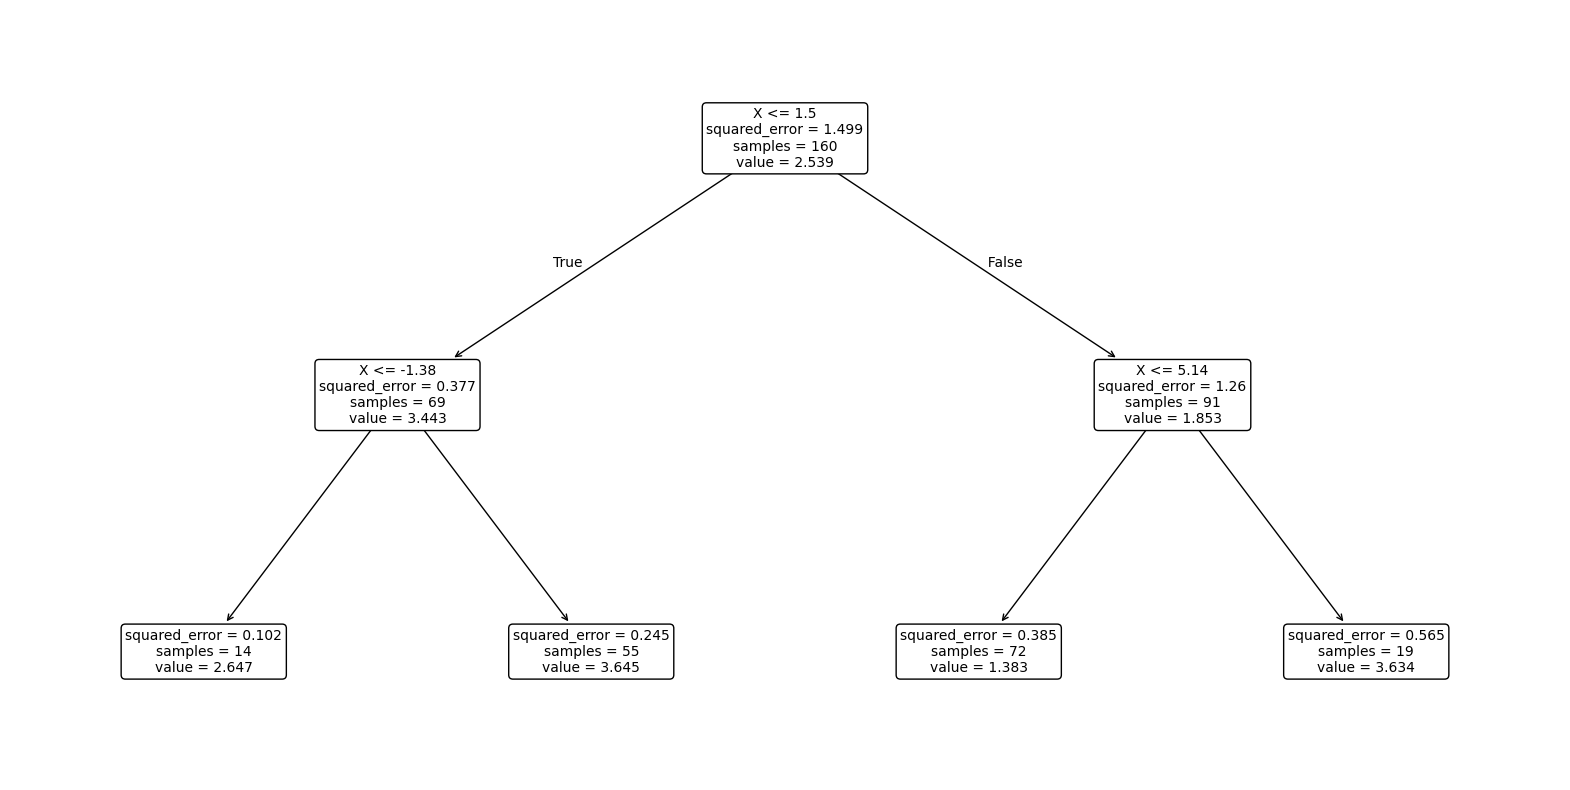

決定木の深さ2の可視化が decision_tree_visualization_depth2.svg に保存されました．


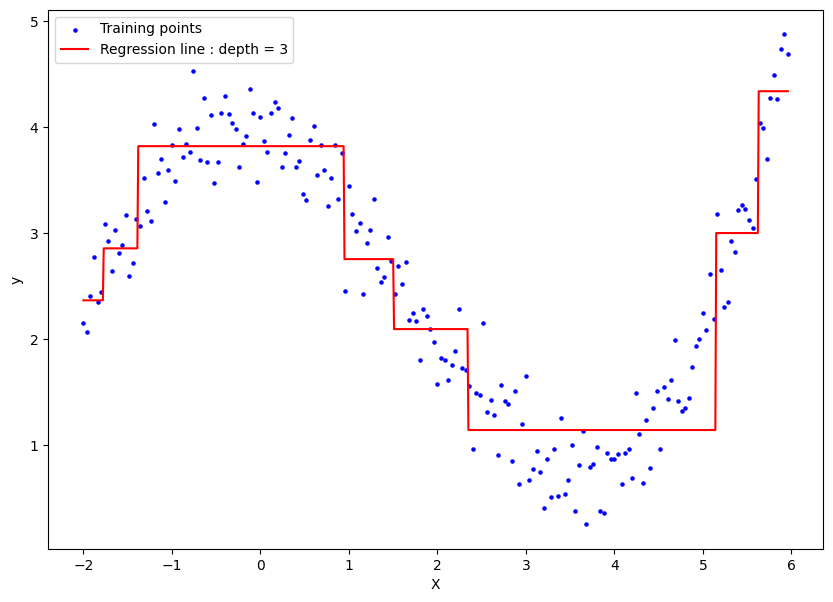

決定木を可視化中（深さ3まで表示）...


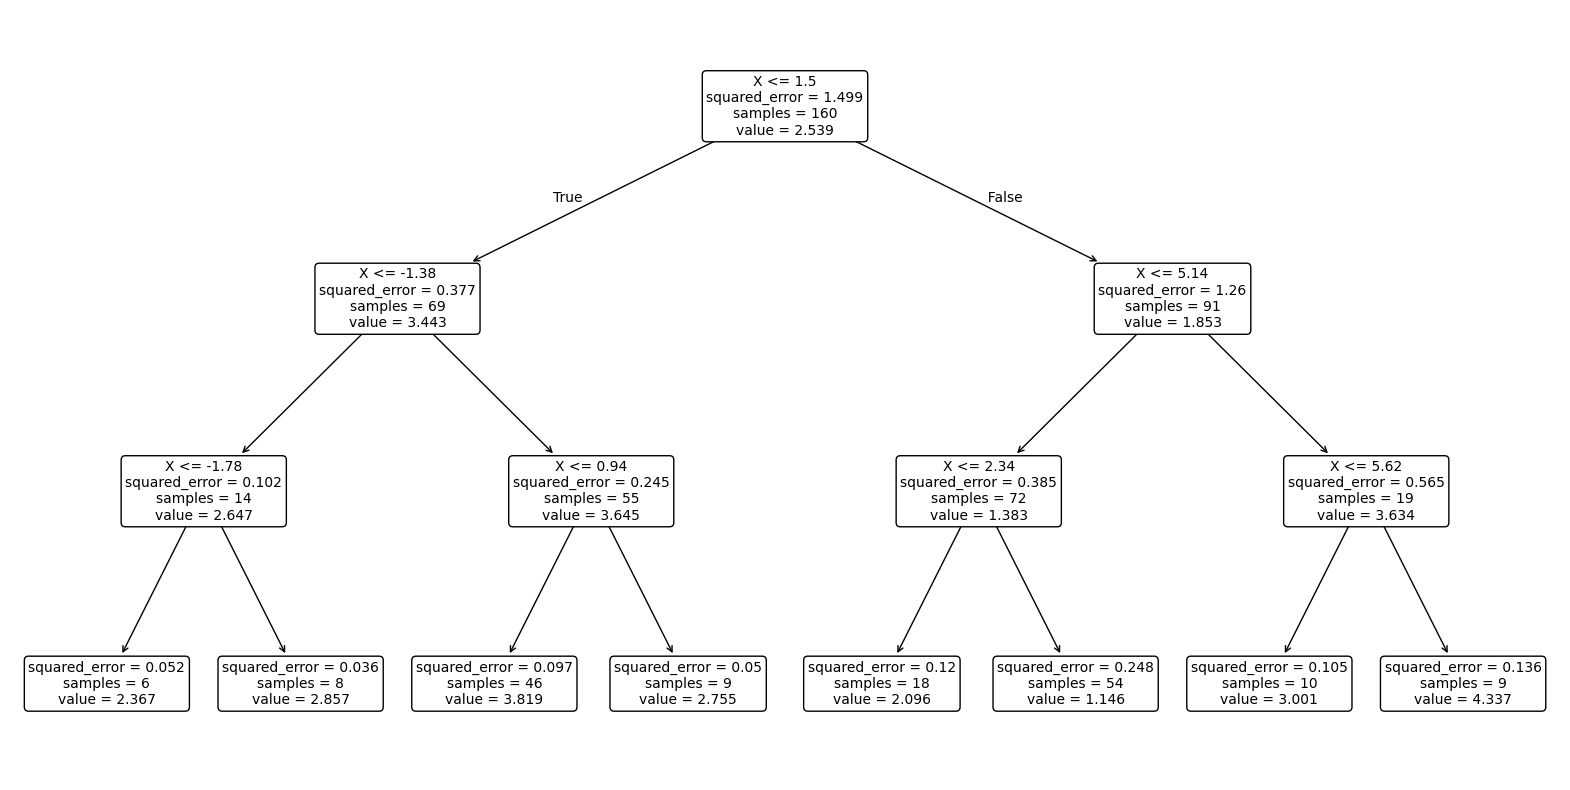

決定木の深さ3の可視化が decision_tree_visualization_depth3.svg に保存されました．


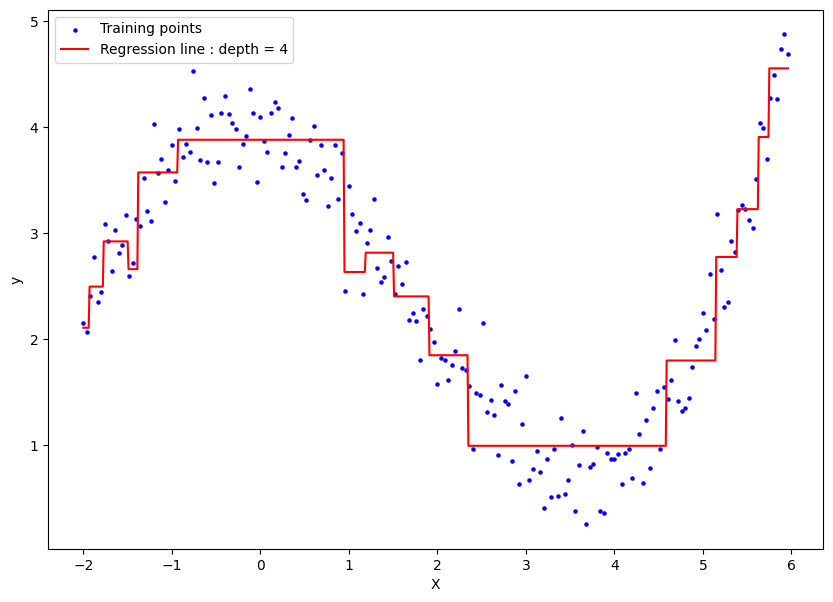

決定木を可視化中（深さ4まで表示）...


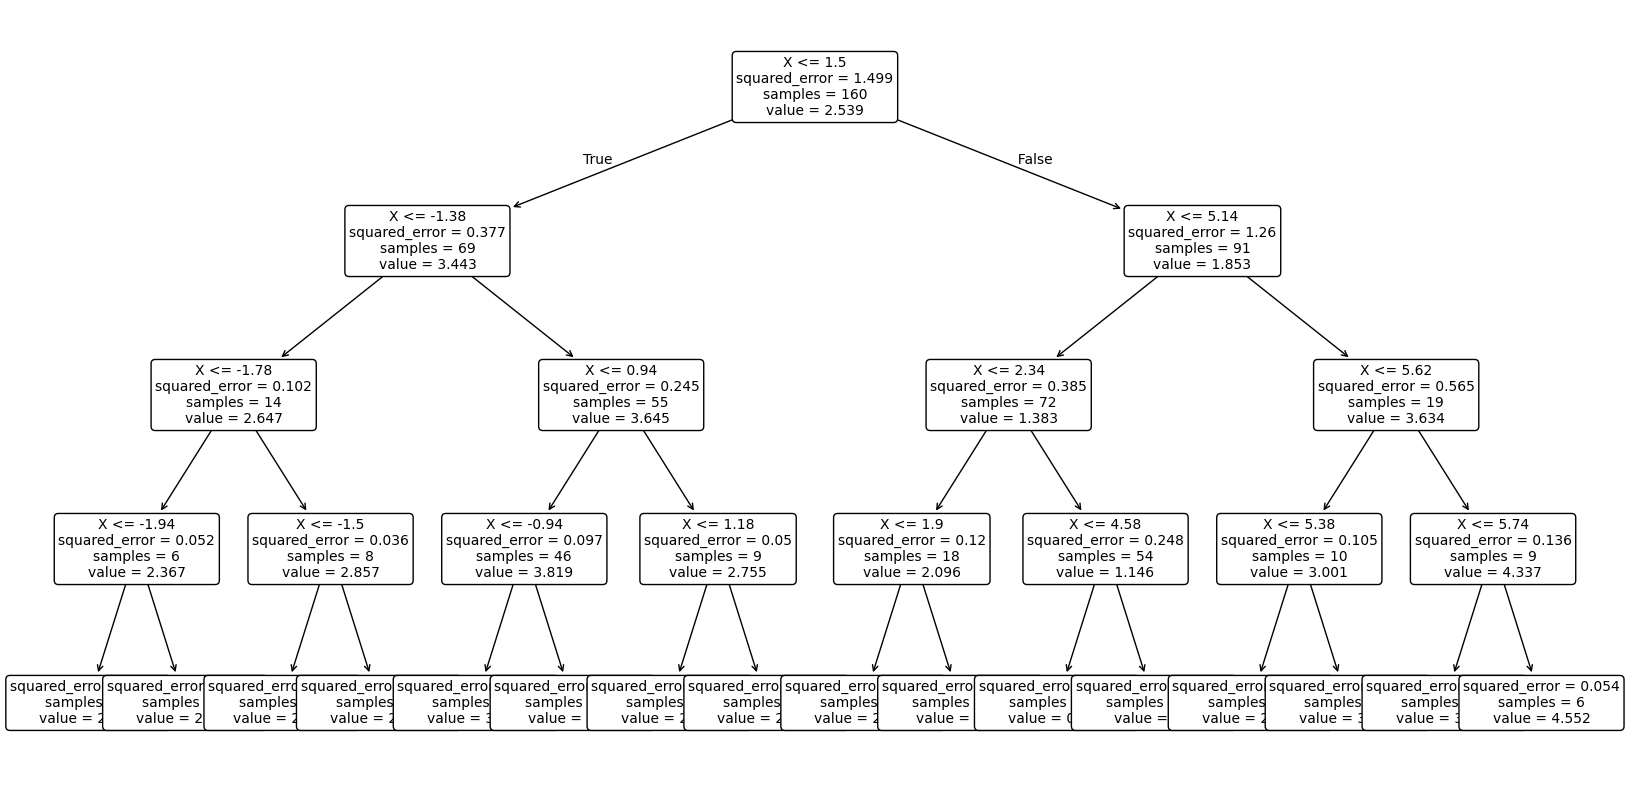

決定木の深さ4の可視化が decision_tree_visualization_depth4.svg に保存されました．


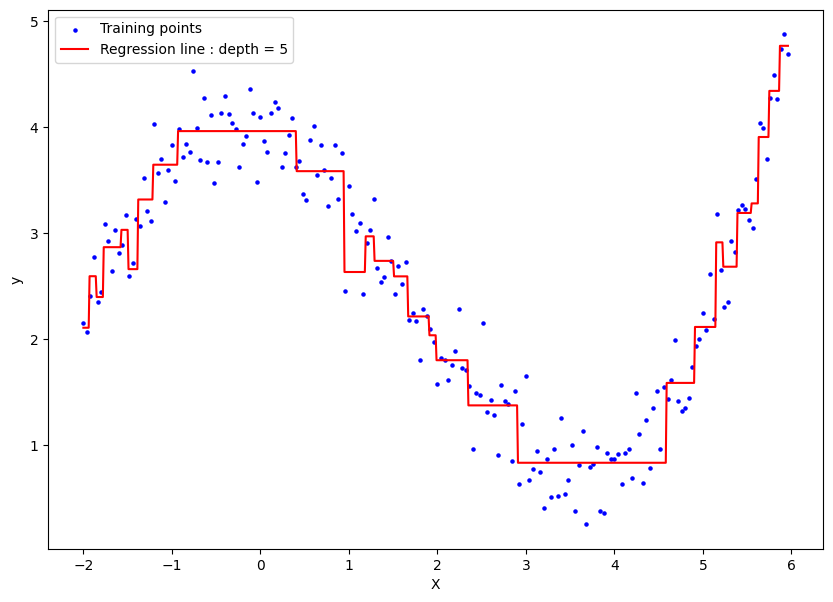

決定木を可視化中（深さ5まで表示）...


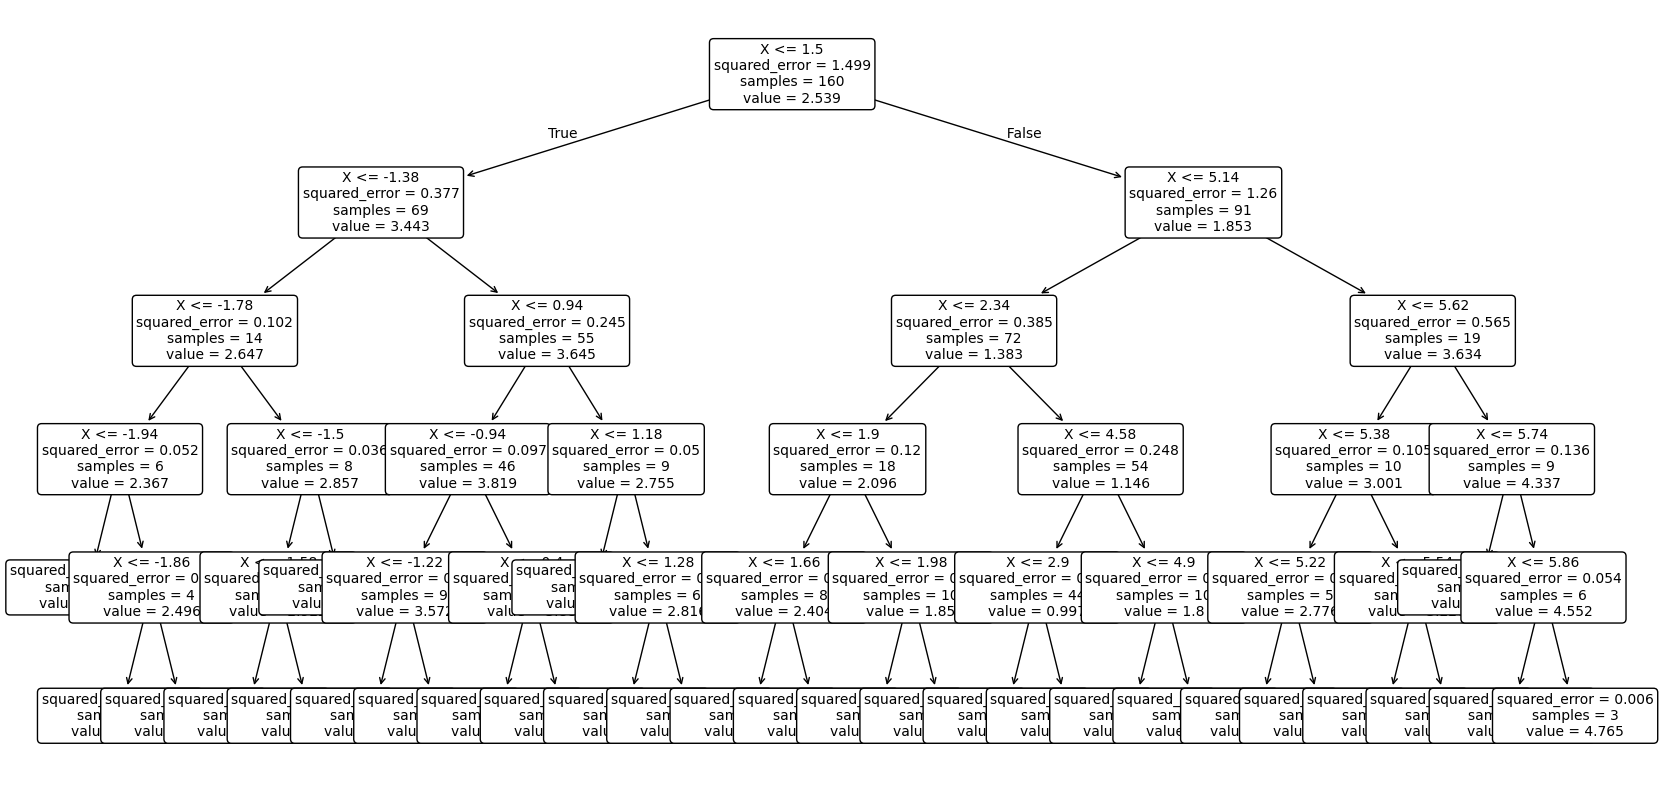

決定木の深さ5の可視化が decision_tree_visualization_depth5.svg に保存されました．


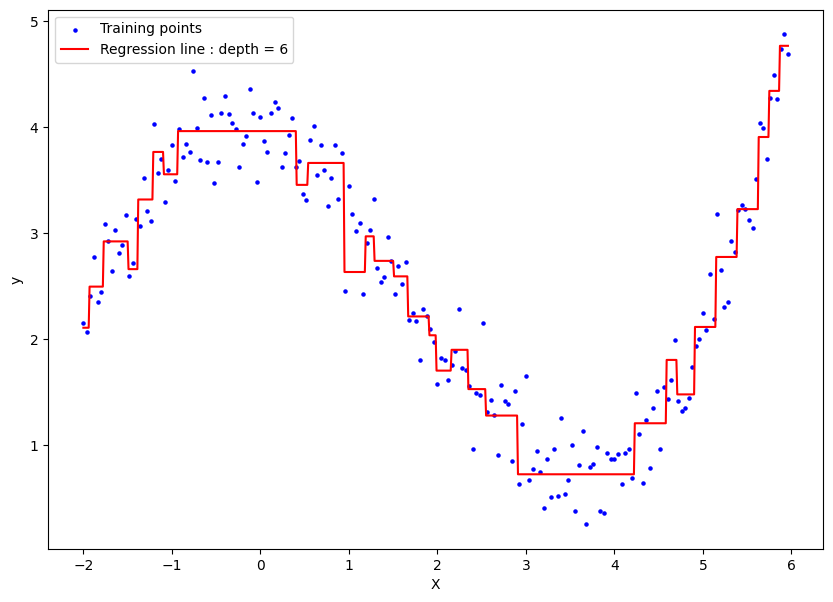

決定木を可視化中（深さ6まで表示）...


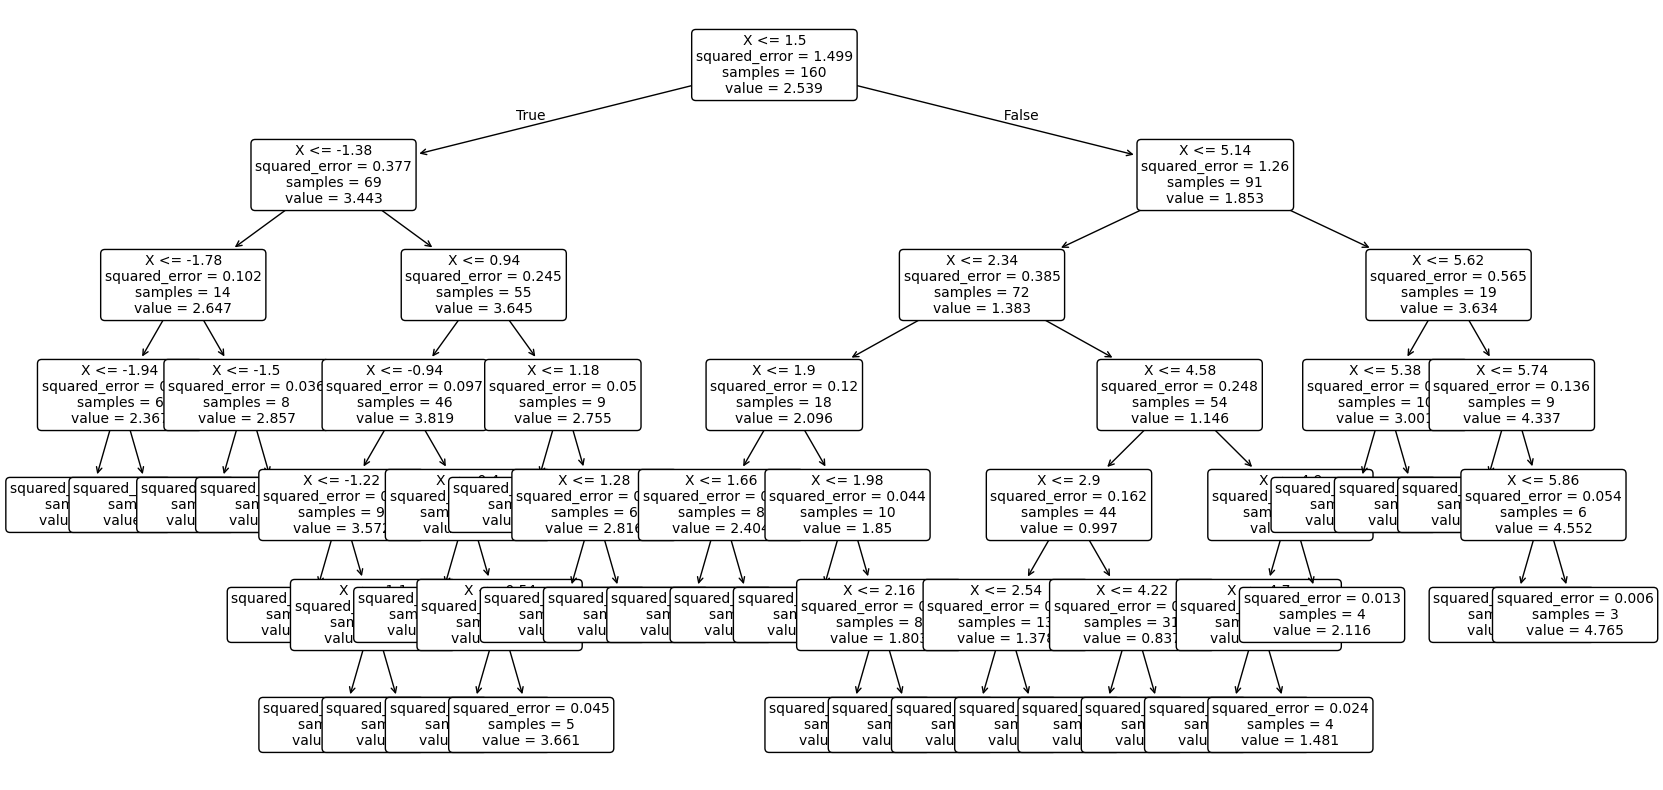

決定木の深さ6の可視化が decision_tree_visualization_depth6.svg に保存されました．


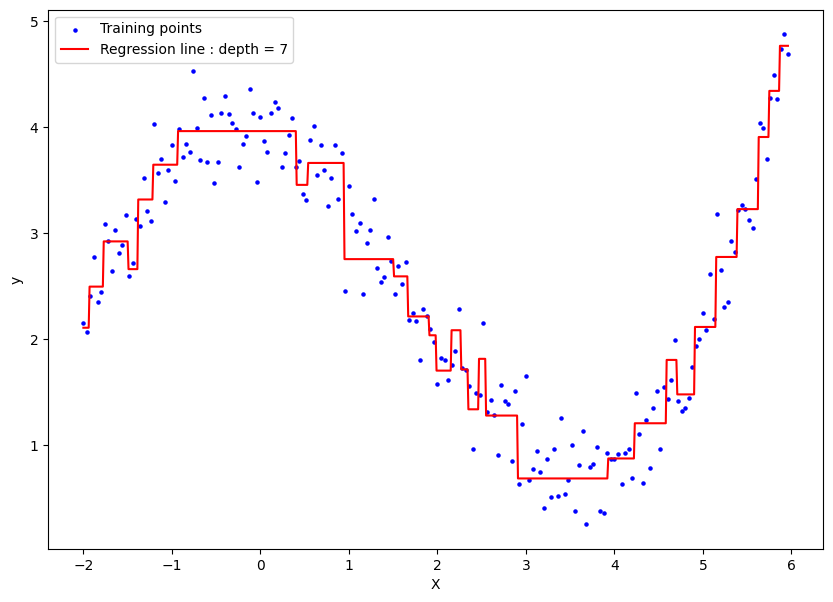

決定木を可視化中（深さ7まで表示）...


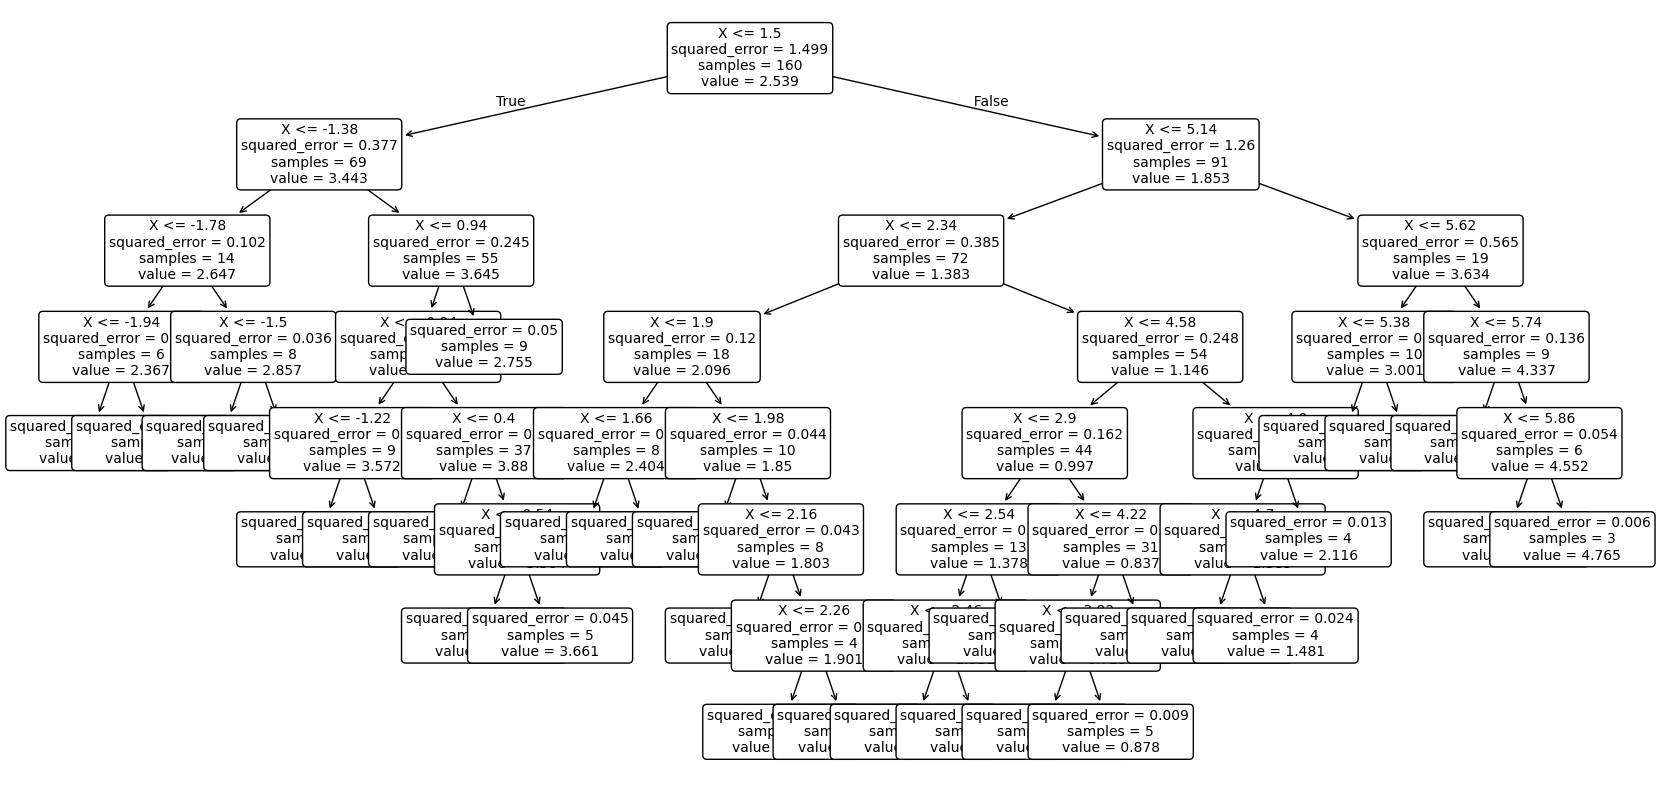

決定木の深さ7の可視化が decision_tree_visualization_depth7.svg に保存されました．


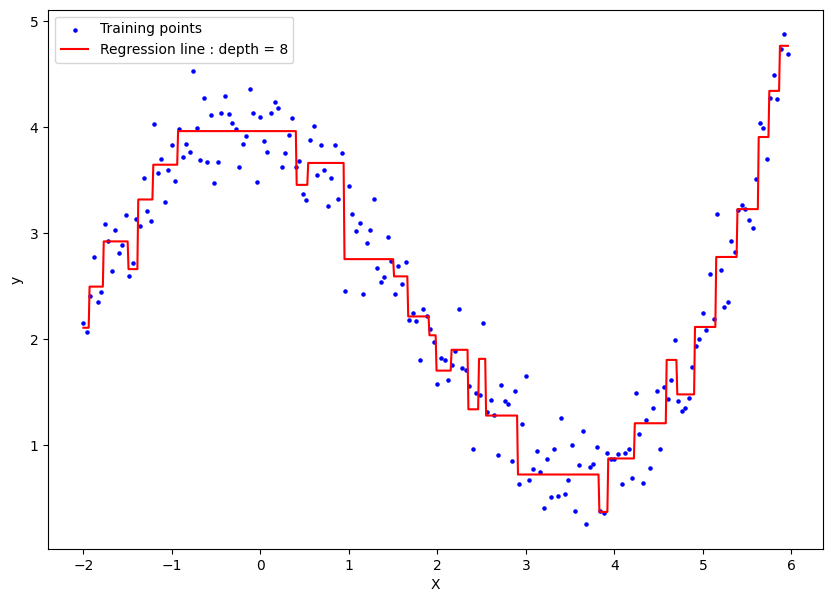

決定木を可視化中（深さ8まで表示）...


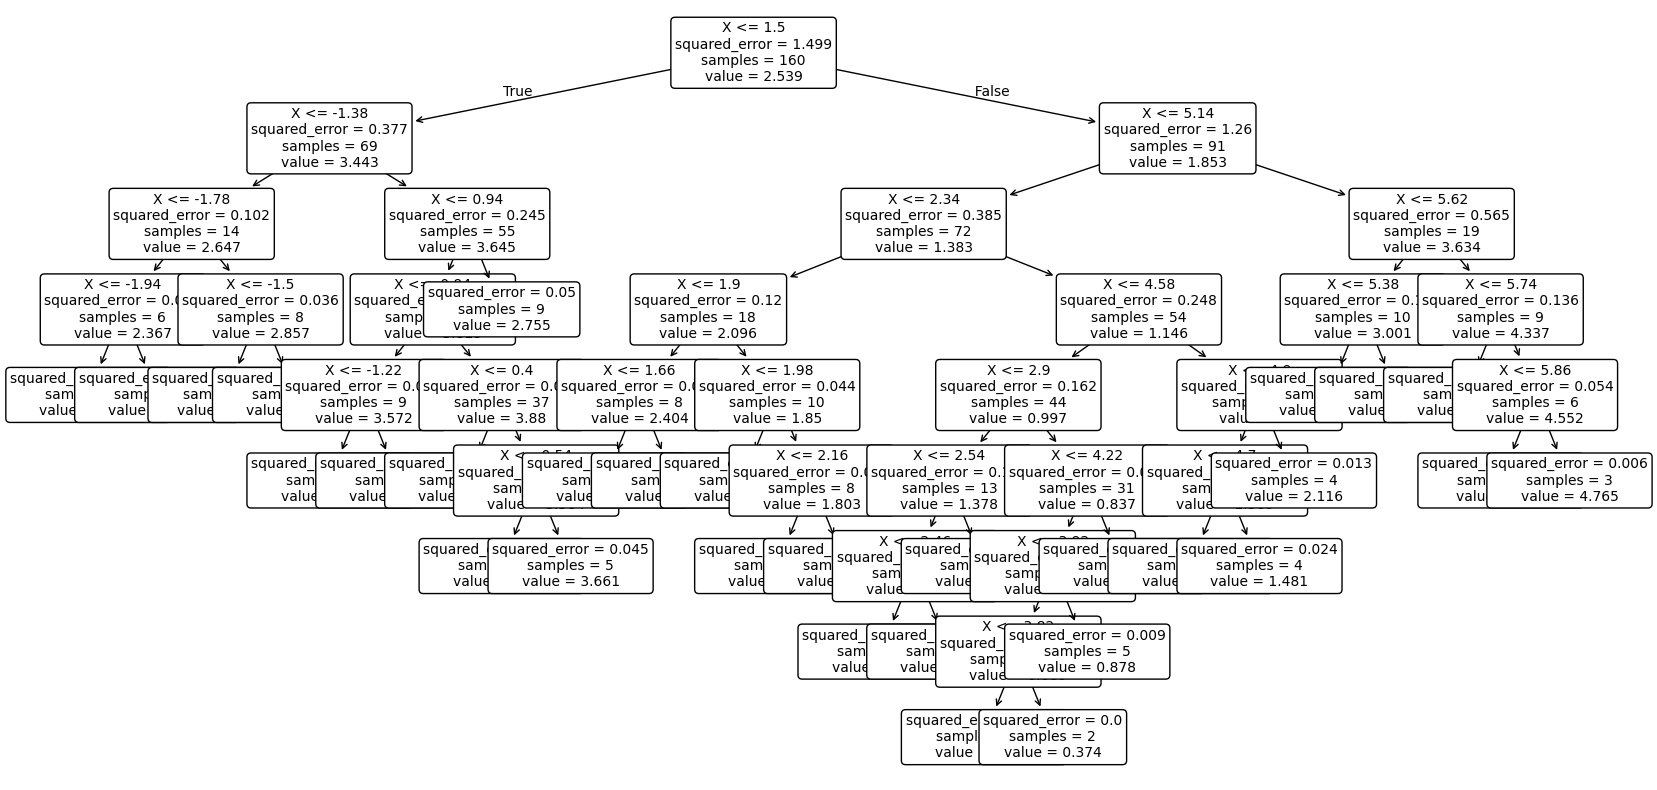

決定木の深さ8の可視化が decision_tree_visualization_depth8.svg に保存されました．


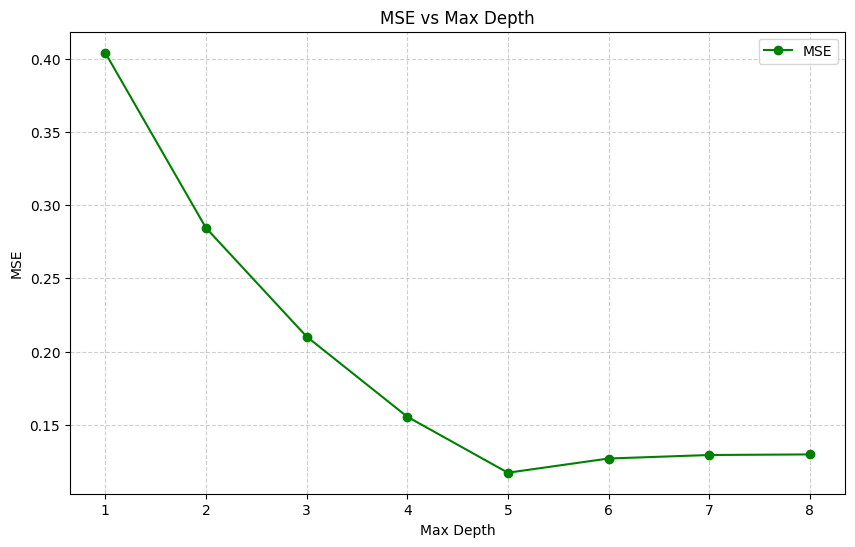

<Figure size 640x480 with 0 Axes>

In [10]:
max_depths = range(1, 9) # 1から8まで
mse_scores = []
for max_depth in max_depths:
    tree = build_tree(max_depth=max_depth)
    # 決定木を構築
    tree.fit(X_train,y_train)
    # 回帰直線を図示するのに変数を並び替え
    sort_idx = X.flatten().argsort()
    X_step = np.arange(X.min(), X.max(), 0.01).reshape(-1, 1)
    # プロット
    plt.figure(figsize = (10, 7))
    plt.scatter(X[sort_idx], y[sort_idx], c = 'blue', label = 'Training points', s=5)
    plt.plot(X_step, tree.predict(X_step), color = 'red', label = 'Regression line : depth = '+str(max_depth))
    # plt.plot(X[sort_idx], tree.predict(X[sort_idx]), color = 'red', label = 'Regression line : depth = '+str(max_depth))
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend(loc = 'upper left')

    plt.savefig("regression_4dPol_depth"+str(max_depth)+".svg")
    plt.show()

    # 決定木の可視化（深さをmax_depthで制限）
    print(f"決定木を可視化中（深さ{max_depth}まで表示）...")
    plt.figure(figsize=(20, 10))
    plot_tree(
        tree,
        feature_names=["X"],  # 特徴量名
        filled=False,
        rounded=True,
        fontsize=10,
        max_depth=max_depth  # 深さの制限
    )

    # SVG形式で保存
    tree_plot_file = f"decision_tree_visualization_depth{max_depth}.svg"
    plt.savefig(tree_plot_file, format="svg")
    plt.show()

    print(f"決定木の深さ{max_depth}の可視化が {tree_plot_file} に保存されました．")

    # 評価指標の計算(テストデータ)
    y_pred = tree.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_scores.append(mse)

# MSEグラフの描画
plt.figure(figsize=(10, 6))
plt.plot(max_depths, mse_scores, marker='o', color='green', label='MSE')
plt.title('MSE vs Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(max_depths) # x軸のメモリを1刻みに

plt.show()
tree_plot_file = f"decision_tree_MSE_vs_Max_Depth.svg"
plt.savefig(tree_plot_file, format="svg")

以下，上のコードの出力結果について解説します．

<br>

**深さ1の分割（ルート分割）**

初めにルートノードを分割した結果です．

<br>

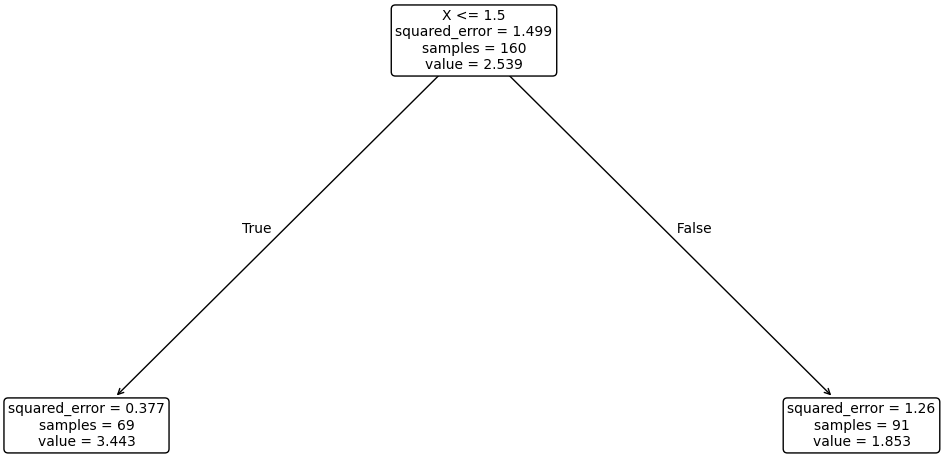

(a) データ分割

<br>

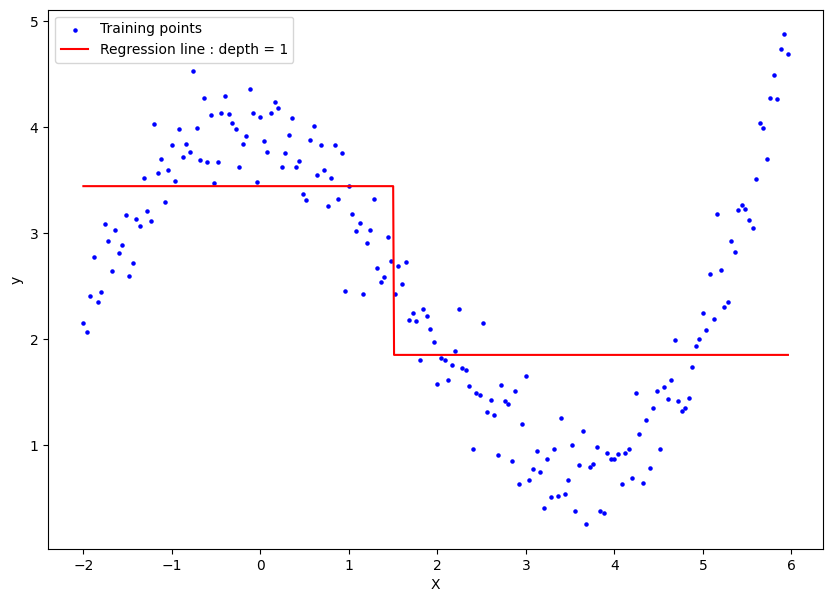

(b) 散布図と予測値

<br>

図1 深さ1の分割

<br>

初めは，全てのトレーニングデータ160個が1つの大きなグループ（ルートノード）に入っています．ルートノードの箱の中にある「samples=160」が，データの個数を表します．「value=2.539」は，その160個のデータにおけるターゲット $y$ の正解値の平均値です．

特徴量 $X$ の閾値を設定することによって，ルートノードのデータを2つに分割します．上のコードでは分割する際の損失関数を MSE に設定したので，MSE の加重平均が最小になるような閾値をアルゴリズムが探します．結果，このトレーニングデータセットでは，閾値1.5以下か否かで2つの子ノードが生成されました．リーフノードが2つなので図1(b)の予測値が，$X = 1.5$ を境に左側は3.443，右側は1.853となっています．左側の3.443という値は，$X \leq 1.5$ を満たすデータ点のターゲット $y$ の平均値です．一方，右側の1.853という値は，$X > 1.5$ を満たすデータ点のターゲット $y$ の平均値です．

ルートノードの箱の中にある「squared_error=1.499」は，$y$ の平均値（回帰木による予測値）とトレーニングデータの各 $y$（正解値）との差を2乗して総和をとり，データ数160で割ったもの，つまり $y$ の予測値の MSE です．すなわち，ルートノードのトレーニングデータ160個のターゲット $y$ の値（正解値）を $y_{0k}\ (k = 1,2,\dots,160)$ とし，その平均値を $\overline{y_{0}}$ とすると，ルートノードの平均二乗誤差 $\mathrm{MSE}_{0}$ は

$$\text{MSE}_{0} = \frac{1}{160}\sum_{k = 1}^{160}\left( y_{0k} - \overline{y_{0}} \right)^{2} = 1.499$$

と書けます．なお，回帰木による予測値はトレーニングデータの $y$（正解値）の平均値なので，$\mathrm{MSE}_{0}$ はノード内のデータ点の分散に等しくなっています．

ここで，ルートノードを分割基準により子ノード $1L$ と $1R$ に分割します．1という数字はノードの深さを表し，$L$ や $R$ は左右 (Left, Right) を表します．

True 側すなわち左側の子ノード $1L$ の69個のターゲット $y$ の値を $y_{1Lk}\ (k = 1,2,\dots,69)$ とし，その平均値を $\overline{y_{1L}}$（回帰木による予測値）とすると，このノードの平均二乗誤差 $\mathrm{MSE}_{1L}$ は，次のようになります．

$$\mathrm{MSE}_{1L} = \frac{1}{69}\sum_{k = 1}^{69}\left( y_{1Lk} - \overline{y_{1L}} \right)^{2} = 0.377$$

同様に，False 側すなわち右側の子ノード $1R$ の平均二乗誤差 $\mathrm{MSE}_{1R}$ は，次のようになります．

$$\mathrm{MSE}_{1R} = \frac{1}{91}\sum_{k = 1}^{91}\left( y_{1Rk} - \overline{y_{1R}} \right)^{2} = 1.26$$

したがって，加重平均 $\mathrm{MSE}_{1w}$ は，

$$\mathrm{MSE}_{1w} = \frac{69}{160}\mathrm{MSE}_{1L} + \frac{91}{160}\mathrm{MSE}_{1R} = \frac{69}{160}0.377 + \frac{91}{160}1.26 = 0.879$$

となり，$\text{MSE}_{1w} < \text{MSE}_{0}( = 1.499)$となっていることがわかります．

<br>

**深さ2の分割**

上で生成した2つの子ノードを，さらに分割します．リーフノードが4つになります．

<br>

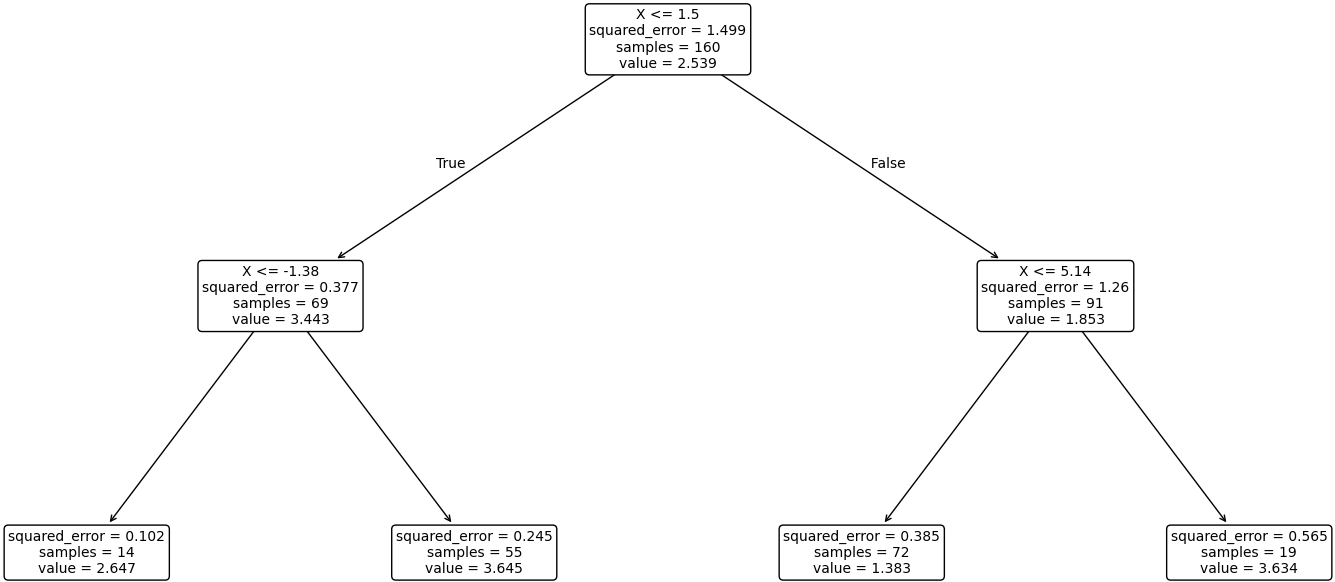

(a) データ分割

<br>

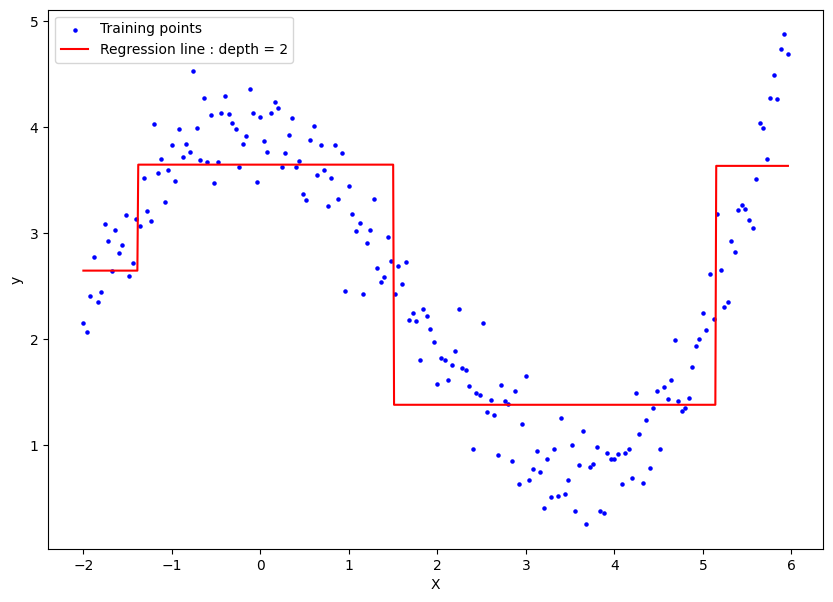

(b) 散布図と予測値

<br>

図2 深さ2の分割

<br>

**深さ3の分割**


<br>

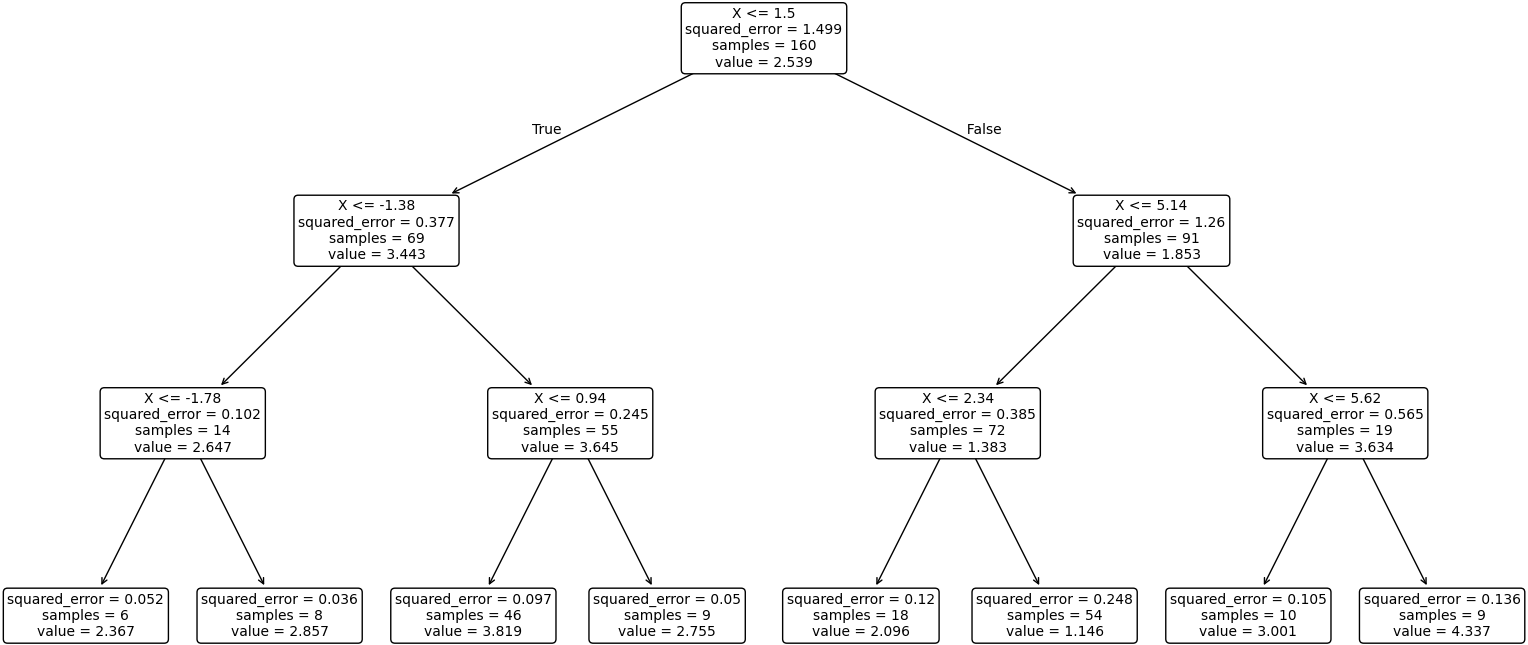

(a) データ分割

<br>

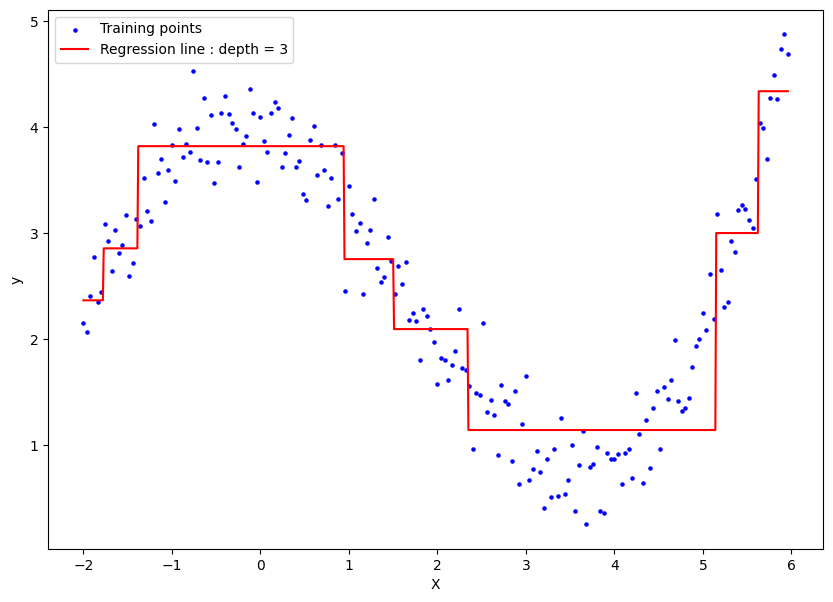

(b) 散布図と予測値

<br>

図3 深さ3の分割

<br>

深さを大きくすることで，分割条件が増加し，予測値（赤いライン）が階段状により細かく調整されていく様子が観察できます．深さ1では，ルートノードでの1回の分割によりデータ全体を2つの領域に分けるのみですが，深さを増やしていくことで領域が細分化され，モデルがデータの曲線的なパターンをより忠実に捉えるようになります．上のコードを実行すると，深さ8までの予測結果の変化を視覚的に確認できます．

<br>

**MSEと最大深さの関係**

また，最大深さの変化に伴うテストデータに対する予測精度の推移を，MSE のグラフで確認します．これを見ると，最大深さが5になるまでは MSE が急激に減少し，モデルの性能が向上していることがわかります．しかし，それ以上深さを増やしても MSE は減少せず，むしろ横ばい（あるいは微増）となっています．これは，深さ5の時点でデータの主要なパターンを十分に学習しており，これ以上モデルを複雑にしても，未知のデータに対する予測能力は向上しない（過学習の領域に入り始めている）ことを示唆しています．

<br>

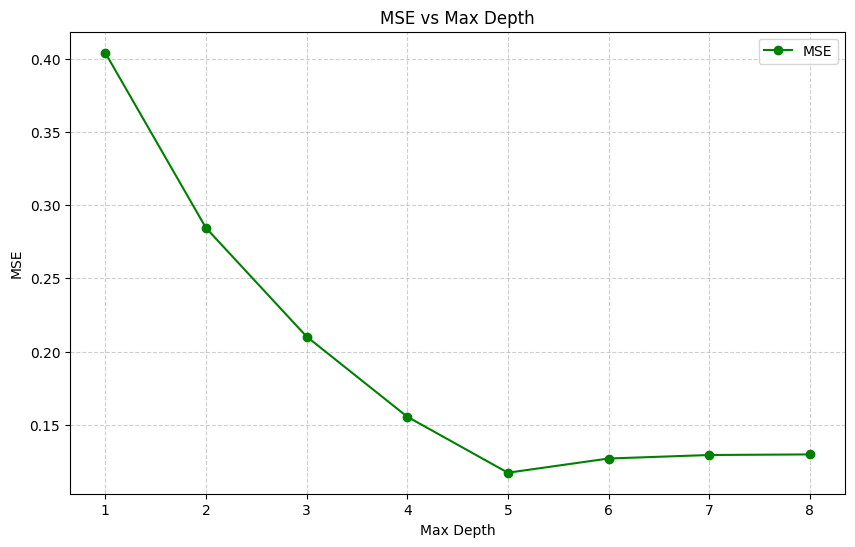

図4 MSEと最大深さの関係